In [3]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [4]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [5]:
zoom = False
composite_years = [1982, 1987, 1991, 1997, 2015, 2009]


## Ocean Mask

In [6]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
#ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
ocean_mask = masks.seamask # all tropical oceans


# SST change

In [7]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [8]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


In [9]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20,-20)).where(ocean_mask)

In [10]:
weights = np.cos(np.deg2rad(sst.lat))

#yearly average Jan-Sept
sst_y = sst.where((sst.time.dt.month<=9) & (sst.time.dt.month>=4)).groupby('time.year').mean()

#change in sst_y
d_sst = sst_y - sst_y.roll(year = 1)


In [11]:
d_2023 = d_sst.sel(year = 2023)


In [12]:
d_composite = d_sst.where(d_sst.year.isin(composite_years), drop = True)

In [13]:
diff = d_2023-d_composite.mean('year')


## mask to check comparision

In [14]:
comparision = d_2023.sst>d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

/tmp/ipykernel_2773802/3277289356.py:100: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


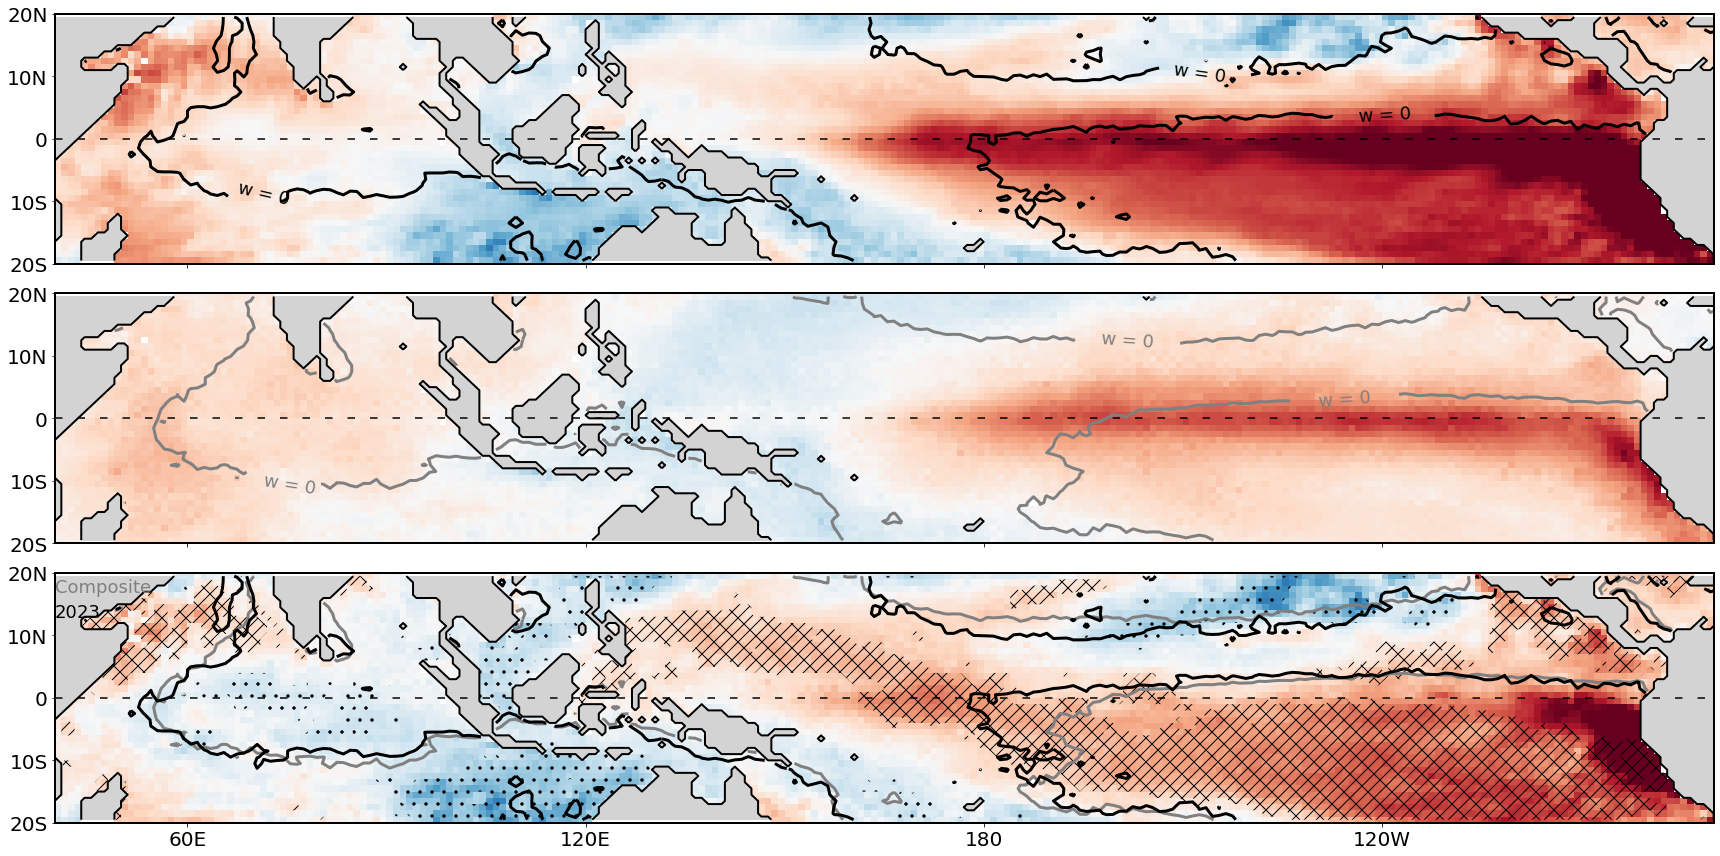

In [15]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, add_colorbar = False)#label=r'$\Delta SST [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking psotive
comparision = d_2023.sst>d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""


#------------------significance masking negatie
comparision = d_2023.sst<d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60E', '120E', '180', '120W']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20S', '10S', '0', '10N', '20N'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(40, 17, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(40, 13, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines

for ax in axes:
    ax.axhline(0, linestyle=(0, (5, 10)), c = 'k')
    ax.set_xlim(40, 290)



plt.tight_layout()
fig.savefig('output/Fig2a.svg', dpi = 600, bbox_inches='tight')


/tmp/ipykernel_2773802/1959771521.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔSST [K]')


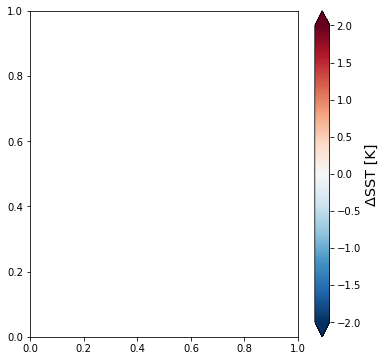

In [16]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, extend = 'both', label = 'ΔSST [K]')
plt.savefig('output/Fig2acbar.svg', dpi = 600, bbox_inches='tight')


# N

In [17]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

In [18]:
#convert to w/m2
n = n/(60**2*24)
#total short and longwave
n['n'] = n.tsr+n.ttr

#weights
weights = np.cos(np.deg2rad(n.lat))

In [19]:
n_mean = n.weighted(weights).mean(['lat', 'lon'])
clim = n_mean.groupby('time.month').mean()
n_anom = n_mean.groupby('time.month')-clim

In [20]:
#make rolling mean
n = n.rolling(time = 3, center = True, min_periods = 1).mean()

In [21]:
weights = np.cos(np.deg2rad(n.lat))

In [22]:
#total short and longwave
n['n'] = n.tsr+n.ttr

In [23]:
# Calculate climatology (1990-2020)
n['n_clim'] = n.sel(time=slice('1991-01-01', '2020-12-31')).groupby('time.month').mean('time').n

# Calculate anomalies
n['n_anom'] = n.n.groupby('time.month') - n.n_clim

In [24]:
y = 2023
sel1 = n.sel(time = str(y)).where((n.time.dt.month<=9)&(n.time.dt.month>=4)).mean('time')
sel2 = n.sel(time = str(y-1)).where((n.time.dt.month<=9)&(n.time.dt.month>=4)).mean('time')

delta_n23 = sel1-sel2

In [25]:
composite_years = [1982, 1987, 1991, 1997, 2015, 2009]


In [26]:

#select year 0s
n_sel1 = n.where((n.time.dt.year.isin(composite_years)) & (n.time.dt.month <= 9) &(n.time.dt.month>=4))
n_sel1 = n_sel1.mean('time')

#select year -1
n_sel2 = n.where((n.time.dt.year.isin([y-1 for y in composite_years])) & (n.time.dt.month <= 9)&(n.time.dt.month>=4))
n_sel2 = n_sel2.mean('time')


#compute delta
delta_ncomposite = n_sel1-n_sel2

In [27]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]

#JantoSept
n_JS = n.where((n.time.dt.month <= 9)&(n.time.dt.month>=4), drop = True).n_anom
n_JS = n_JS.groupby('time.year').mean('time')


#take difference between years
diff_JS = n_JS - n_JS.roll(year = 1)

#select composite years
diff_JS = diff_JS.where(diff_JS.year.isin(composite_years), drop = True)


In [28]:
delta_ndiff = delta_n23 - delta_ncomposite

In [29]:
change = delta_ndiff.n_anom
a = delta_n23.n_anom
b = diff_JS

In [30]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [31]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


In [32]:
comparision = a>b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/plot/plot.py:1415: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/tmp/ipykernel_2773802/105185503.py:152: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


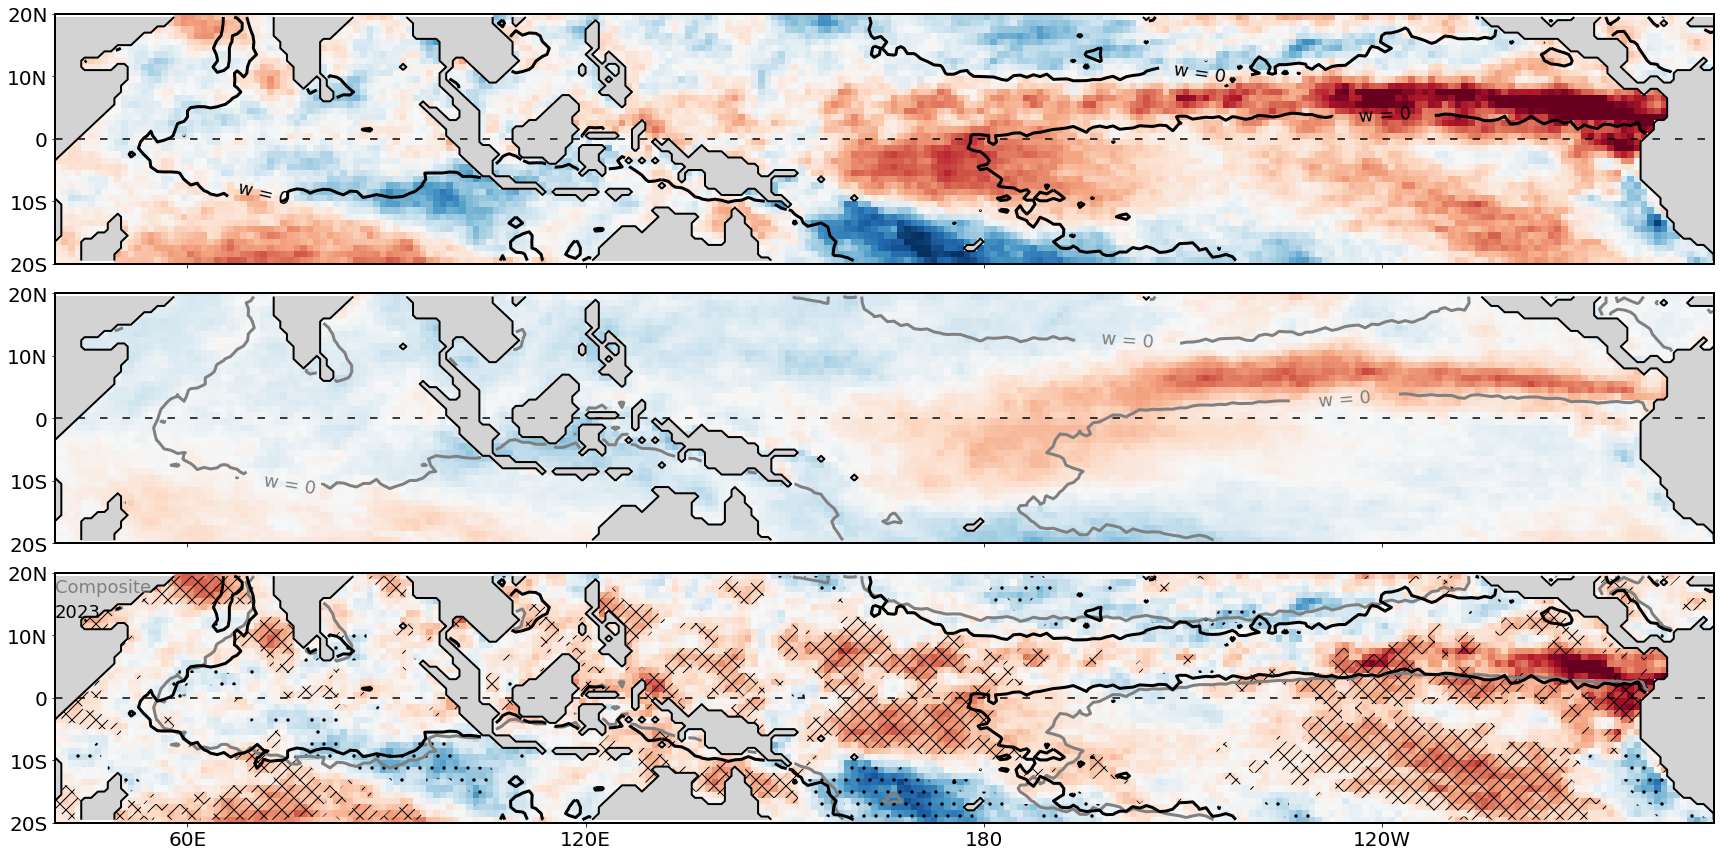

In [33]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


# Define boundaries for discrete levels
bounds = np.linspace(-20,20 , 11)  # 10 discrete intervals between -20 and 20
norm = BoundaryNorm(boundaries=bounds, ncolors=18)

norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = delta_n23.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[0], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


axes[0].set_ylabel('Latitude')
axes[0].set_xlabel('')


# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors= 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')


#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ncomposite.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[1], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[1], label = 'N Change [W/m2]')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)


axes[1].set_ylabel('Latitude')
axes[1].set_xlabel('')
axes[1].set_title('')



#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ndiff.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[2], 
    add_colorbar=False
)

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], label = 'composite', colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', label = '2023', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')
#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')




#------------------significance masking positive
comparision = a>b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5
# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""
# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""

#------------------significance masking negative

comparision = a<b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5
"""# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['..'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""

# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60E', '120E', '180', '120W']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20S', '10S', '0', '10N', '20N'], fontsize=20)
    
#    ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)



#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(40, 17, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(40, 13, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines

for ax in axes:
    ax.axhline(0, linestyle=(0, (5, 10)), c = 'k')
    ax.set_xlim(40, 290)




plt.tight_layout()
fig.savefig('output/Fig2d.svg', dpi = 600, bbox_inches='tight')


/tmp/ipykernel_2773802/1215483065.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, orientation = 'vertical', extend = 'both', label = 'ΔN [W/m2]')


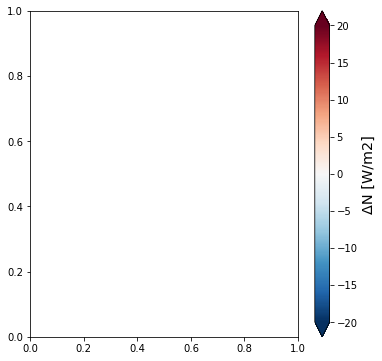

In [39]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, orientation = 'vertical', extend = 'both', label = 'ΔN [W/m2]')
plt.savefig('output/Fig2dcbar.svg', dpi = 600, bbox_inches='tight')


## Changes by vertical motion

In [40]:
def prepare_composite_data(w500, var_dataset, varname, years, ocean_mask, months=[4, 5, 6, 7, 8, 9], bin_count=10):

    w_climatology = w500.sel(time=slice('1991', '2020')).where(
        w500.time.dt.month.isin(months)
    ).mean('time')

    w_flat = w_climatology['w'].values.flatten()
    w_flat = w_flat[~np.isnan(w_flat)]
    quantile_centers = np.linspace(0.05, 0.95, bin_count)
    bin_centers = np.quantile(w_flat, quantile_centers)

    edges = np.zeros(len(bin_centers) + 1)
    edges[1:-1] = (bin_centers[:-1] + bin_centers[1:]) / 2
    edges[0] = w_flat.min() - 1e-6
    edges[-1] = w_flat.max() + 1e-6

    all_data = []
    for year in years:
        year_str = str(year)
        prev_year_str = str(year - 1)

        var_this = var_dataset[varname].sel(time=slice(f'{year_str}-04', f'{year_str}-09')).mean('time')
        var_prev = var_dataset[varname].sel(time=slice(f'{prev_year_str}-04', f'{prev_year_str}-09')).mean('time')
        delta_var = var_this - var_prev

        w_values = w_climatology['w'].values
        delta_values = delta_var.values
        valid_mask = ~np.isnan(delta_values) & ~np.isnan(w_values)

        w_clean = w_values[valid_mask]
        delta_clean = delta_values[valid_mask]

        bin_indices = np.digitize(w_clean, bins=edges)
        year_data = pd.DataFrame({
            'Year': year,
            'Bin': bin_indices,
            'Bin Center': [bin_centers[i - 1] if 0 < i <= len(bin_centers) else np.nan for i in bin_indices],
            'Delta Var': delta_clean
        })
        year_data.dropna(inplace=True)
        all_data.append(year_data)

    return pd.concat(all_data, ignore_index=True)


In [41]:
def aggregate_composite_data(data):
    grouped = data.groupby('Bin Center')['Delta Var'].agg(['mean', 'std']).reset_index()
    grouped.columns = ['Bin Center', 'Delta Mean', 'Delta Std']
    return grouped


In [42]:
def plot_composite_bins(grouped_comp, grouped_year, var_label='ΔVar [units]', legend = True):
    fig, ax = plt.subplots(figsize=(6, 5))
    offset = 1.2

    composite_x = grouped_comp['Bin Center'] - offset
    year_x = grouped_year['Bin Center'] + offset

    ax.errorbar(
        composite_x,
        grouped_comp['Delta Mean'],
        yerr=grouped_comp['Delta Std'],
        fmt='o', capsize=4, label='Composite', color='k',
        markersize = 8
    )

    ax.errorbar(
        year_x,
        grouped_year['Delta Mean'],
        yerr=grouped_year['Delta Std'],
        fmt='o', capsize=4, label='2023', color='red',
        markersize = 8
    )

    ax.set_xlim(-60, 35)
    if 'SST' in var_label:
        ax.set_ylim(-1, 3.)
    elif 'CC' in var_label:
        ax.set_ylim(-.16, .16)
    ax.set_xlabel('w₅₀₀ [hPa/day]', fontsize=18, fontweight='normal')
    ax.set_ylabel(var_label, fontsize=18, fontweight='normal')
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(axis='y')

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=2.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=2.5)

    if legend: ax.legend(fontsize=12, loc = 'lower right')
    plt.tight_layout()
    plt.show()
    return fig


In [43]:
def run_composite_analysis(w500, dataset, varname, ocean_mask, composite_years, target_year=2023, var_label=None, legend = True):
    if var_label is None:
        var_label = f'Δ{varname.upper()} [units]'

    comp_data = prepare_composite_data(w500, dataset, varname, composite_years, ocean_mask)
    target_data = prepare_composite_data(w500, dataset, varname, [target_year], ocean_mask)

    comp_grouped = aggregate_composite_data(comp_data)
    target_grouped = aggregate_composite_data(target_data)

    fig = plot_composite_bins(comp_grouped, target_grouped, var_label=var_label, legend = legend)
    return fig


## Load Data

In [44]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

In [45]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20, -20), time = slice('1979', None))
sst = sst.where(ocean_mask)



In [46]:

fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-02'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

clouds = clouds.where(ocean_mask)

In [47]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20), time= slice('1979', None))

w500 = w500.where(ocean_mask)
#convert to hpa/day
w500 = w500*(24*3600/100)




## Computation

In [48]:
composite_years = [1982, 1987, 1991, 1997, 2009, 2015]

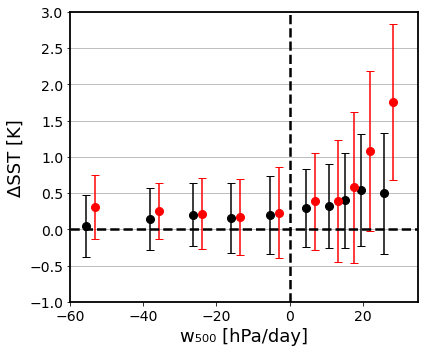

In [49]:
fig = run_composite_analysis(w500, sst, 'sst', ocean_mask, composite_years=composite_years, var_label='ΔSST [K]', legend = False)
fig.savefig('output/Fig2g.svg', dpi = 600, bbox_inches='tight')



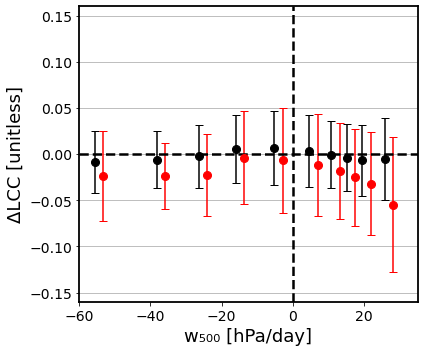

In [52]:
fig = run_composite_analysis(w500, clouds, 'lcc', ocean_mask, composite_years=composite_years, var_label='ΔLCC [unitless]', legend = False)
fig.savefig('output/Fig2h.svg', dpi = 600, bbox_inches='tight')


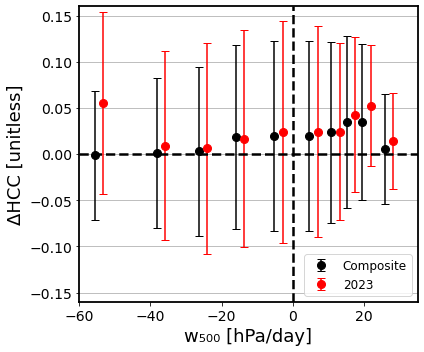

In [53]:
fig = run_composite_analysis(w500, clouds, 'hcc', ocean_mask, composite_years=composite_years, var_label='ΔHCC [unitless]')
fig.savefig('output/Fig2i.svg', dpi = 600, bbox_inches='tight')


## Bar Code

## Ocean Mask

In [ ]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans


# N

In [ ]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

In [ ]:
#convert to w/m2
n = n/(60**2*24)
#total short and longwave
n['n'] = n.tsr+n.ttr

#weights
weights = np.cos(np.deg2rad(n.lat))

In [54]:
#calculate mean over area (weighted)
#calculate yearly april-sept mean
n_mean = n.weighted(weights).mean(['lat', 'lon'])
n_mean = n_mean.where((n_mean.time.dt.month <=9) & (n_mean.time.dt.month >=4)).groupby('time.year').mean('time')

In [55]:
dn_mean = n_mean - n_mean.roll(year = 1)
dn_mean = dn_mean.sel(year = slice(1979, None))

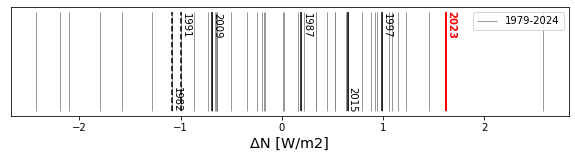

In [57]:

# Assuming dn_mean.n and dn_mean.year exist


composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean.n, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982).n, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991).n, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015).n, ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y).n
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023).n
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [W/m2]")
#ax.set_title("Barcode Plot of dn_mean.n")

plt.legend()
fig.savefig('output/Fig2j.svg', dpi = 600, bbox_inches='tight')
